# BraTS 2024 to NPZ Conversion and Visualization

This notebook converts the BraTS 2024 challenge datasets into a unified `.npz` format for training. It supports both:
- **BraTS-GLI**: Adult glioma post-treatment (MRI sequences: t1c, t1n, t2f, t2w).
- **BraTS-MEN-RT**: Meningioma radiotherapy planning (MRI sequence: t1c).

Only used a small subset for training

In [3]:
import sys
from pathlib import Path
import os
import numpy as np

parent = Path().resolve().parent.parent 
sys.path.append(str(parent))

from data.train_data.brats_to_npz import process_brats_gli, process_brats_men_rt
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Process BraTS-GLI Dataset

Processing the glioma dataset. By default, we use the `t1c` sequence.

In [ ]:
data_dir_gli = "BraTS_2024/BraTS-GLI"
output_gli = "brats_gli"

if os.path.exists(data_dir_gli):
    process_brats_gli(
        data_dir=data_dir_gli, 
        output_path=output_gli,
        sequence="all",
        resample=True,
        max_patients=20
    )
else:
    print(f"Directory {data_dir_gli} not found.")

## 2. Process BraTS-MEN-RT Dataset

Processing the meningioma radiotherapy dataset. Note that this data is in native space and will be resampled to 1.0mm isotropic.

In [ ]:
data_dir_men = "BraTS_2024/BraTS-MEN-RT"
output_men = "brats_men_rt"

if os.path.exists(data_dir_men):
    process_brats_men_rt(
        data_dir=data_dir_men, 
        output_path=output_men, 
        resample=True,
        max_patients=6
    )
else:
    print(f"Directory {data_dir_men} not found.")

## 3. Load and Visualize Results

Now we load the generated `.npz` file and visualize a few samples.

### BraTS_GLI

In [ ]:
# sequences = ["t1c", "t1n", "t2f", "t2w"]

In [14]:
npz_path = f"data/train_data/brats_gli.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: {all_ids}")

sample_id = all_ids[0]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask[0].shape}")


Loading NPZ dataset(s)…
Loaded 20 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\train_data\brats_gli.npz

Final dataset size: 20 patients.

Loaded IDs: ['brats_gli_BraTS-GLI-02481-103', 'brats_gli_BraTS-GLI-02596-101', 'brats_gli_BraTS-GLI-02616-100', 'brats_gli_BraTS-GLI-02504-102', 'brats_gli_BraTS-GLI-02570-105', 'brats_gli_BraTS-GLI-02486-100', 'brats_gli_BraTS-GLI-02420-100', 'brats_gli_BraTS-GLI-02429-101', 'brats_gli_BraTS-GLI-02507-101', 'brats_gli_BraTS-GLI-02618-101', 'brats_gli_BraTS-GLI-02412-100', 'brats_gli_BraTS-GLI-02614-101', 'brats_gli_BraTS-GLI-02418-100', 'brats_gli_BraTS-GLI-02566-100', 'brats_gli_BraTS-GLI-02614-105', 'brats_gli_BraTS-GLI-02534-100', 'brats_gli_BraTS-GLI-02421-100', 'brats_gli_BraTS-GLI-02645-101', 'brats_gli_BraTS-GLI-02591-103', 'brats_gli_BraTS-GLI-02645-100']
Sample: brats_gli_BraTS-GLI-02481-103
Image shape: (95, 193, 160)
Mask shape: (95, 193, 160)


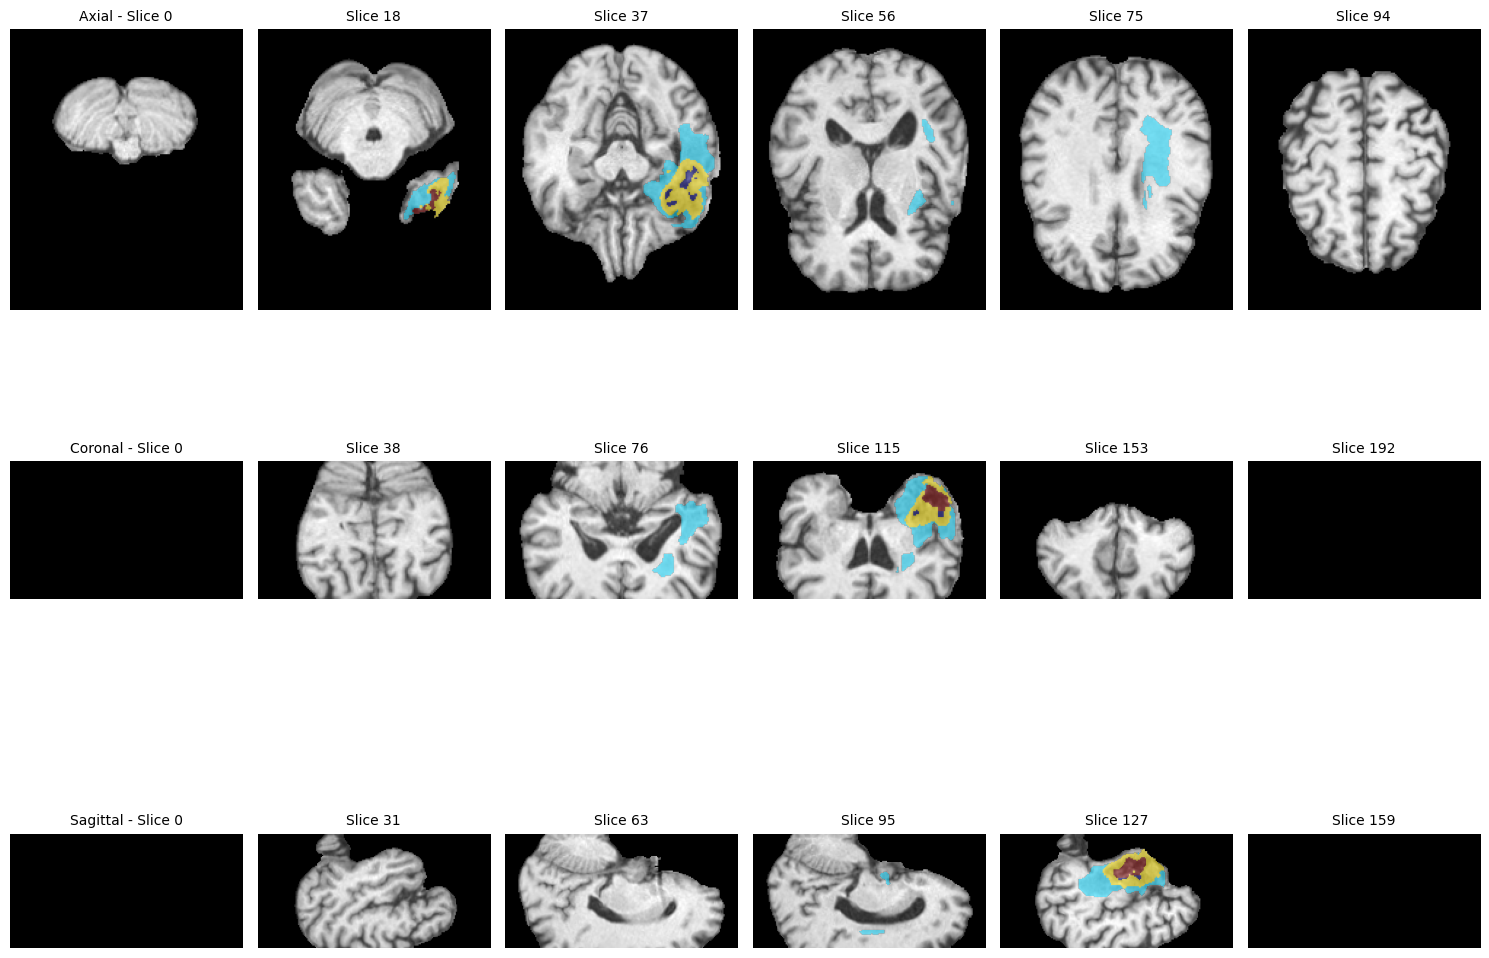

In [15]:
plot_vol_slices(img, mask[0], num_slices=6) #t2w

In [8]:
x_np, y_np, p_np, m_np, offset_list = dg.get_data_points_numpy(max_data_points=100, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 0 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].


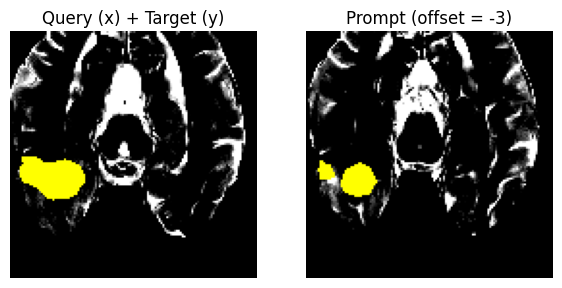

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].



x: -5.0 - 3.71761155128479 | y: 0.0 - 1.0 | p (img): -5.0 - 3.71761155128479 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


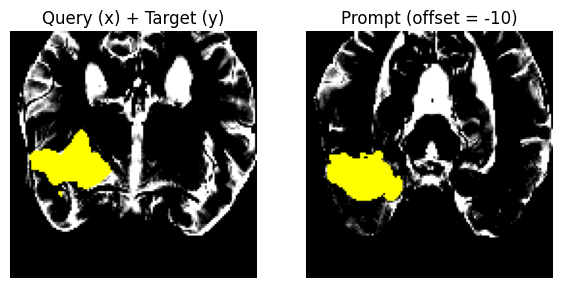

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].



x: -5.0 - 3.71761155128479 | y: 0.0 - 1.0 | p (img): -5.0 - 3.71761155128479 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


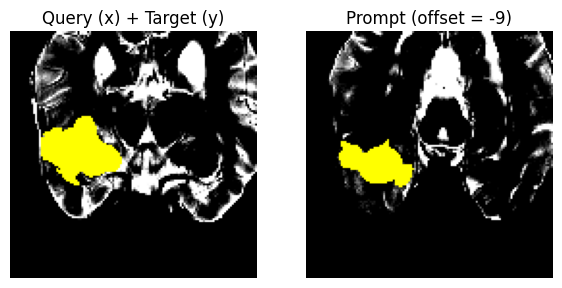

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].



x: -5.0 - 3.71761155128479 | y: 0.0 - 1.0 | p (img): -5.0 - 3.71761155128479 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


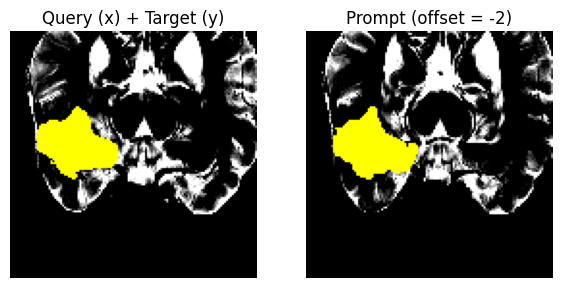

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].



x: -5.0 - 3.71761155128479 | y: 0.0 - 1.0 | p (img): -5.0 - 3.71761155128479 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


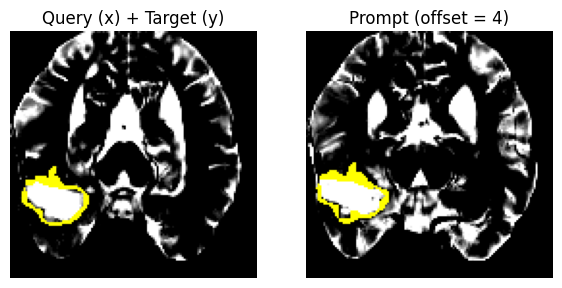

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7176116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.7032783].



x: -5.0 - 3.71761155128479 | y: 0.0 - 1.0 | p (img): -5.0 - 3.71761155128479 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


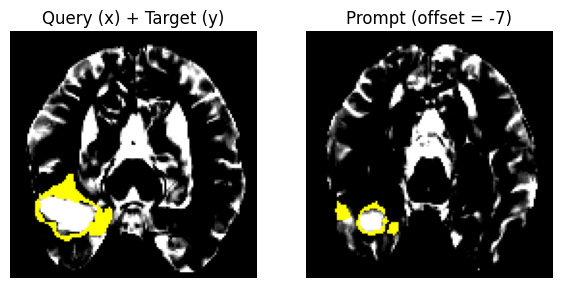


x: -5.0 - 3.71761155128479 | y: 0.0 - 1.0 | p (img): -5.0 - 3.7032783031463623 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


In [9]:
for dp_idx in range(x_np.shape[0]):
    x, y, p = x_np[dp_idx,...], y_np[dp_idx,...], p_np[dp_idx,...]
    plot_one_dp(x,y,p, offset_list[dp_idx])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if dp_idx == 5:
        break

### BraTS-MEN-RT

In [11]:
npz_path = f"data/train_data/brats_men_rt.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: {all_ids}")

sample_id = all_ids[0]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask[0].shape}")


Loading NPZ dataset(s)…
Loaded 6 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\train_data\brats_men_rt.npz

Final dataset size: 6 patients.

Loaded IDs: ['brats_men_rt_BraTS-MEN-RT-0029-1', 'brats_men_rt_BraTS-MEN-RT-0562-1', 'brats_men_rt_BraTS-MEN-RT-0467-1', 'brats_men_rt_BraTS-MEN-RT-0006-1', 'brats_men_rt_BraTS-MEN-RT-0450-1', 'brats_men_rt_BraTS-MEN-RT-0524-1']
Sample: brats_men_rt_BraTS-MEN-RT-0029-1
Image shape: (176, 240, 240)
Mask shape: (176, 240, 240)


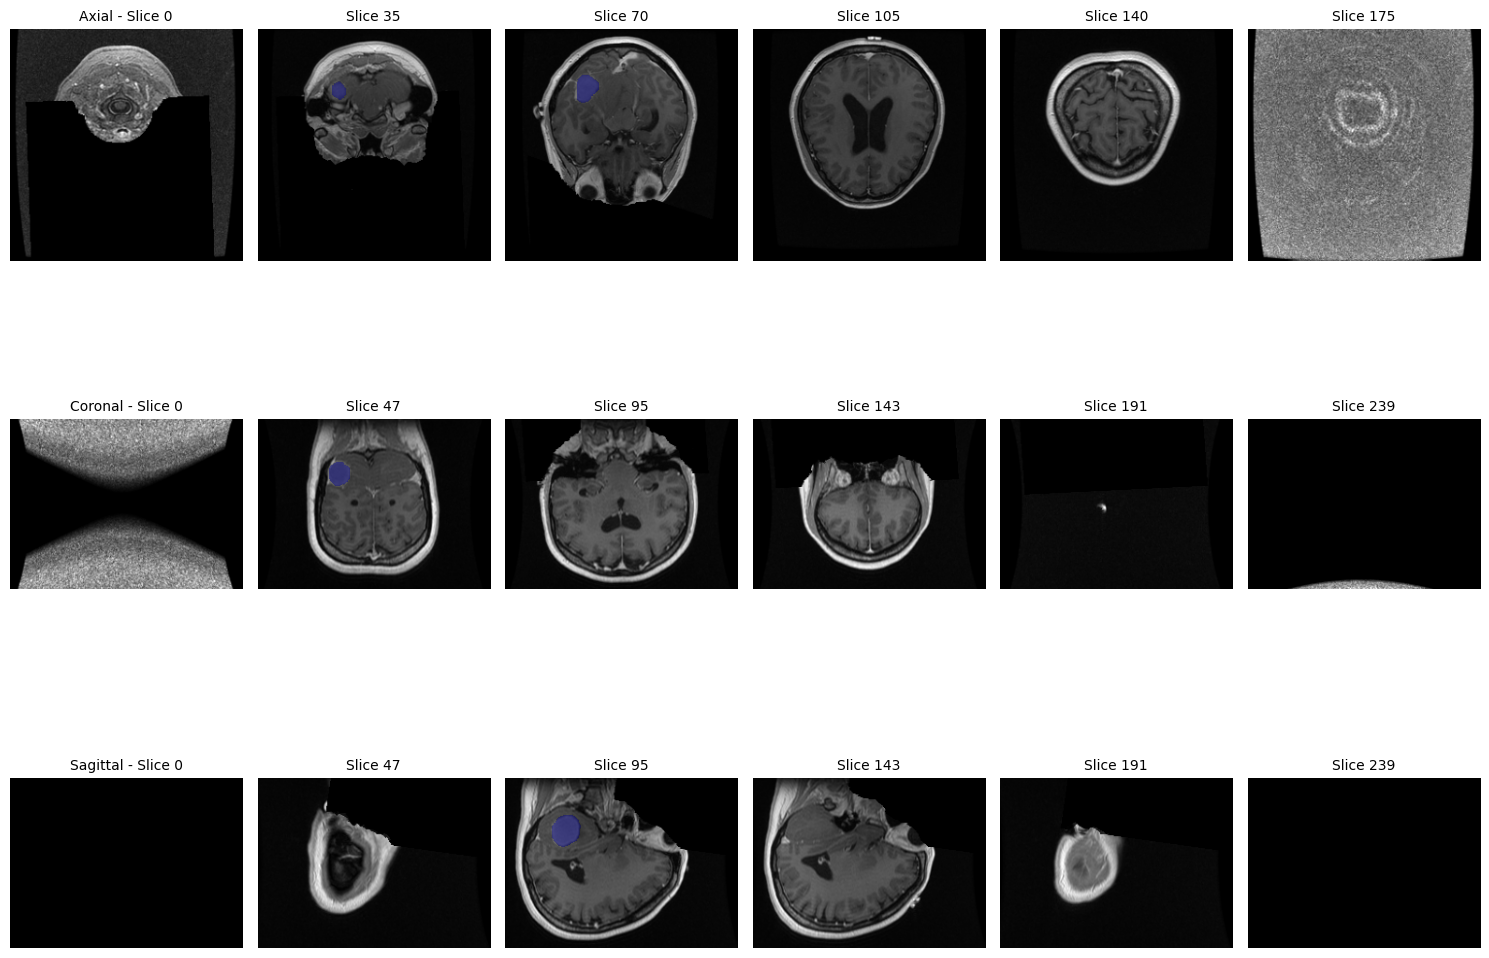

In [12]:
plot_vol_slices(img, mask[0], num_slices=6) 